<a href="https://colab.research.google.com/github/samriddhi-m1227/EV_Analysis-CS163Capstone/blob/main/eda_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Summary

## Overview

This project analyzes electric vehicle (EV) adoption and charging infrastructure across California ZIP codes.  
To support this analysis, multiple datasets were combined into a single unified dataset.

**NOTE**: The dataset integrates information from several sources:

- **EV vehicle registration data (CalMatters)** used to measure vehicle composition and EV adoption
- **American Community Survey (ACS)** for demographic and socioeconomic indicators
- **CalEnviroScreen environmental justice metrics**
- **NREL EV charging infrastructure data**

All datasets were standardized and merged using **ZIP code as the geographic key**, resulting in a unified dataset for analysis. check out get_data.ipynb for the detailed ingestion.

The final dataset contains:

- **1,427 ZIP codes**
- **35 variables**

Each row represents a **single ZIP code in California**.

---

# Data Dictionary

## Geographic Identifier

These variables identify the geographic region of each observation.

- **ZIP**  ZIP code identifier for each observation.

- **County**  California county corresponding to the ZIP code.

---

# Vehicle Composition Variables

These variables describe the distribution of vehicle fuel types registered in each ZIP code.

- **Diesel**  Number of diesel vehicles registered.

- **Electric**  Number of fully electric vehicles.

- **Flex_Fuel**  Number of flex-fuel vehicles.

- **Gasoline**  Number of gasoline vehicles.

- **Gasoline_Hybrid**  Number of hybrid gasoline vehicles.

- **Hydrogen**  Number of hydrogen fuel cell vehicles.

- **Natural_Gas**  Number of natural gas vehicles.

- **PHEV**  Number of plug-in hybrid electric vehicles.

- **Propane**  Number of propane vehicles.

- **Total_Cars**  Total number of vehicles registered in the ZIP code.

---

# Electric Vehicle Adoption Metrics

These variables summarize EV presence in each ZIP code.

- **Total_EV**  Total number of electric vehicles (sum of battery electric and plug-in hybrid vehicles).

- **EV_perc**  Percentage of vehicles that are electric.  
This variable serves as the **primary target variable** for analysis.

---

# Demographic and Socioeconomic Indicators

- **Median_Household_Income**  Median household income in the ZIP code.

- **Total_Population**  Total population residing in the ZIP code.

- **Latino_perc**  Percentage of residents identifying as Latino.

- **White_perc**  Percentage of residents identifying as White.

- **Asian_perc**  Percentage of residents identifying as Asian.

- **Black_perc**  Percentage of residents identifying as Black.

- **BachOrHigher_perc**  Percentage of residents with a bachelor's degree or higher.

---

# Housing and Economic Structure

These variables describe housing characteristics and economic inequality within each ZIP code.

- **Zillow_Home_Value_Index**  Estimated average housing value in the ZIP code.

- **Gini**  Income inequality index.From 0 to 1. (Lower values is moire equal income dist, whereas higher is greater income inequality)

- **RenterShare**  Share of households that rent their homes.

- **SingleFamilyShare**  Share of housing units that are single-family homes.

- **MultiUnitShare**  Share of housing units that are multi-unit buildings.

- **ZeroVehicleShare**  Share of households without access to a vehicle.

- **PovertyShare**  Share of residents living below the poverty line. Higher values indicate greater economic disadvantage within the zip code.

---

# Environmental Justice Indicators (CalEnviroScreen)

These variables capture environmental burden and pollution exposure in each ZIP code.

- **CES_Score_ZIP**  Overall CalEnviroScreen score representing environmental and socioeconomic vulnerability. higher score is worse.

- **PollutionBurden_ZIP**  Pollution exposure indicator. The higher the worse

- **Traffic_ZIP**  Traffic-related pollution indicator. Higher means greater exposure to traffic population.

---

# EV Charging Infrastructure

These variables describe the availability of EV charging infrastructure.

- **Num_Stations**  Number of EV charging stations in the ZIP code.

- **Total_Ports**  Total number of charging ports (sum of L2 and Fast Ports)

- **L2_Ports**  Number of Level 2 charging ports.

- **DC_Fast_Ports**  Number of DC fast charging ports.

---

# Dataset Structure Summary

Each observation represents a **ZIP code** and includes information about:

- vehicle composition
- EV adoption levels
- demographic characteristics
- housing and economic conditions
- environmental justice indicators
- EV charging infrastructure availability

This unified dataset allows exploration of **how socioeconomic factors, environmental burden, and infrastructure availability relate to EV adoption across California communities.**

In [ ]:
# --- Setup ---

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

BASE_DIR = "/content/drive/MyDrive/cs 163-capstone"
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

Mounted at /content/drive
DATA_DIR: /content/drive/MyDrive/cs 163-capstone/data
OUTPUT_DIR: /content/drive/MyDrive/cs 163-capstone/outputs


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
np.random.seed(163)

In [ ]:
final_path = os.path.join(DATA_DIR, "final.csv")
final=pd.read_csv(final_path)
final.head()

,ZIP,Diesel,Electric,Flex_Fuel,Gasoline,Gasoline_Hybrid,Hydrogen,Natural_Gas,PHEV,Propane,Total_Cars,Total_EV,EV_perc,Median_Household_Income,Latino_perc,White_perc,Asian_perc,Black_perc,BachOrHigher_perc,Total_Population,Zillow_Home_Value_Index,Gini,RenterShare,SingleFamilyShare,MultiUnitShare,ZeroVehicleShare,PovertyShare,CES_Score_ZIP,PollutionBurden_ZIP,Traffic_ZIP,County,Num_Stations,Total_Ports,L2_Ports,DC_Fast_Ports
0,94027,89,723,137,4764,380,1,0,167,0,6261,891,14.23,250001.0,8.8,68.0,18.5,1.2,84.7,7213,7397088.91,0.5047,0.115487,1.000000,0.000000,0.009735,0.033789,4.965985,4.938998,584.975507,San Mateo,1.0,2.0,2.0,0.0
1,94022,228,1880,255,12682,1416,8,1,502,0,16972,2390,14.08,250001.0,5.2,53.7,36.2,0.2,87.6,20069,4383734.10,0.4986,0.197026,0.846250,0.152745,0.022305,0.030119,4.278299,4.142339,1103.700570,Santa Clara,17.0,153.0,133.0,20.0
2,94301,141,1229,163,8513,1141,5,5,352,0,11549,1586,13.73,184932.0,6.2,59.6,24.4,2.5,82.0,17243,3763337.05,0.5426,0.446466,0.584333,0.415667,0.099370,0.043670,7.792235,3.983527,563.050330,Santa Clara,15.0,65.0,64.0,1.0
3,94028,128,645,110,4451,609,1,1,188,0,6133,834,13.60,250001.0,9.0,79.5,5.9,0.0,85.2,6582,3708911.26,0.4921,0.133763,0.907373,0.092627,0.038276,0.032767,5.139967,4.151575,714.839738,San Mateo,2.0,4.0,4.0,0.0
4,94024,253,1981,246,14374,1649,12,3,571,0,19089,2564,13.43,250001.0,6.3,55.6,31.7,0.9,85.1,24203,3879869.05,0.4602,0.123569,0.972871,0.027129,0.012444,0.024339,6.942833,4.068953,822.684235,Santa Clara,2.0,30.0,26.0,4.0


In [ ]:
final.columns.to_list() #details on each column ^ is in the data card.

['ZIP',
 'Diesel',
 'Electric',
 'Flex_Fuel',
 'Gasoline',
 'Gasoline_Hybrid',
 'Hydrogen',
 'Natural_Gas',
 'PHEV',
 'Propane',
 'Total_Cars',
 'Total_EV',
 'EV_perc',
 'Median_Household_Income',
 'Latino_perc',
 'White_perc',
 'Asian_perc',
 'Black_perc',
 'BachOrHigher_perc',
 'Total_Population',
 'Zillow_Home_Value_Index',
 'Gini',
 'RenterShare',
 'SingleFamilyShare',
 'MultiUnitShare',
 'ZeroVehicleShare',
 'PovertyShare',
 'CES_Score_ZIP',
 'PollutionBurden_ZIP',
 'Traffic_ZIP',
 'County',
 'Num_Stations',
 'Total_Ports',
 'L2_Ports',
 'DC_Fast_Ports']

In [ ]:
#rename final to df
df=final.copy()

print("Dataset shape:", df.shape)
display(df.head(5))

TARGET = "EV_perc"
df_clean = df.dropna(subset=[TARGET]).copy()

if "ZIP" in df_clean.columns:
    df_clean["ZIP"] = df_clean["ZIP"].astype(str).str.zfill(5)

print("After dropping missing target:", df_clean.shape)



Dataset shape: (1427, 35)


,ZIP,Diesel,Electric,Flex_Fuel,Gasoline,Gasoline_Hybrid,Hydrogen,Natural_Gas,PHEV,Propane,Total_Cars,Total_EV,EV_perc,Median_Household_Income,Latino_perc,White_perc,Asian_perc,Black_perc,BachOrHigher_perc,Total_Population,Zillow_Home_Value_Index,Gini,RenterShare,SingleFamilyShare,MultiUnitShare,ZeroVehicleShare,PovertyShare,CES_Score_ZIP,PollutionBurden_ZIP,Traffic_ZIP,County,Num_Stations,Total_Ports,L2_Ports,DC_Fast_Ports
0,94027,89,723,137,4764,380,1,0,167,0,6261,891,14.23,250001.0,8.8,68.0,18.5,1.2,84.7,7213,7397088.91,0.5047,0.115487,1.000000,0.000000,0.009735,0.033789,4.965985,4.938998,584.975507,San Mateo,1.0,2.0,2.0,0.0
1,94022,228,1880,255,12682,1416,8,1,502,0,16972,2390,14.08,250001.0,5.2,53.7,36.2,0.2,87.6,20069,4383734.10,0.4986,0.197026,0.846250,0.152745,0.022305,0.030119,4.278299,4.142339,1103.700570,Santa Clara,17.0,153.0,133.0,20.0
2,94301,141,1229,163,8513,1141,5,5,352,0,11549,1586,13.73,184932.0,6.2,59.6,24.4,2.5,82.0,17243,3763337.05,0.5426,0.446466,0.584333,0.415667,0.099370,0.043670,7.792235,3.983527,563.050330,Santa Clara,15.0,65.0,64.0,1.0
3,94028,128,645,110,4451,609,1,1,188,0,6133,834,13.60,250001.0,9.0,79.5,5.9,0.0,85.2,6582,3708911.26,0.4921,0.133763,0.907373,0.092627,0.038276,0.032767,5.139967,4.151575,714.839738,San Mateo,2.0,4.0,4.0,0.0
4,94024,253,1981,246,14374,1649,12,3,571,0,19089,2564,13.43,250001.0,6.3,55.6,31.7,0.9,85.1,24203,3879869.05,0.4602,0.123569,0.972871,0.027129,0.012444,0.024339,6.942833,4.068953,822.684235,Santa Clara,2.0,30.0,26.0,4.0


After dropping missing target: (1427, 35)


In [ ]:
# 1) DATASET SUMMARY

# columns and then top columns with missing %

print("\n==============================")
print("1) DATASET SUMMARY")
print("==============================")
print("Target variable:", TARGET)

print("\nColumns (n={}):".format(len(df.columns)))
print(df.columns.tolist())

summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values
}).sort_values(["missing_pct", "column"], ascending=[False, True])

print("\nTop columns by missing %:")
display(summary.head(20))


1) DATASET SUMMARY
Target variable: EV_perc

Columns (n=35):
['ZIP', 'Diesel', 'Electric', 'Flex_Fuel', 'Gasoline', 'Gasoline_Hybrid', 'Hydrogen', 'Natural_Gas', 'PHEV', 'Propane', 'Total_Cars', 'Total_EV', 'EV_perc', 'Median_Household_Income', 'Latino_perc', 'White_perc', 'Asian_perc', 'Black_perc', 'BachOrHigher_perc', 'Total_Population', 'Zillow_Home_Value_Index', 'Gini', 'RenterShare', 'SingleFamilyShare', 'MultiUnitShare', 'ZeroVehicleShare', 'PovertyShare', 'CES_Score_ZIP', 'PollutionBurden_ZIP', 'Traffic_ZIP', 'County', 'Num_Stations', 'Total_Ports', 'L2_Ports', 'DC_Fast_Ports']

Top columns by missing %:


,column,dtype,missing_count,missing_pct
27,CES_Score_ZIP,float64,162,11.35
30,County,object,162,11.35
28,PollutionBurden_ZIP,float64,162,11.35
29,Traffic_ZIP,float64,162,11.35
20,Zillow_Home_Value_Index,float64,46,3.22
13,Median_Household_Income,float64,28,1.96
21,Gini,float64,21,1.47
24,MultiUnitShare,float64,19,1.33
22,RenterShare,float64,19,1.33
23,SingleFamilyShare,float64,19,1.33


In [ ]:
# 2) CLEANING & QUALITY CHECKS

print("\n==============================")
print("2) CLEANING & QUALITY CHECKS")
print("==============================")

# 2.1 Missing
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("\nMissing % (top 15):")
display(missing_pct.head(15))

# 2.2 Duplicate ZIPs
if "ZIP" in df.columns:
    print("Duplicate ZIP rows:", df.duplicated(subset=["ZIP"]).sum())
else:
    print("No ZIP column found; duplicate check skipped.")

# 2.3 Race sum plausibility
race_cols = [c for c in ["Latino_perc","White_perc","Asian_perc","Black_perc"] if c in df.columns]
if race_cols:
    race_sum = df[race_cols].sum(axis=1)
    print("\nRace sum stats (min/median/max):", race_sum.min(), race_sum.median(), race_sum.max())
    if race_sum.median() <= 2:
        print("Race variables appear to be proportions (0–1).")
    else:
        print("Race variables appear to be percentages (0–100).")
else:
    print("\nRace columns not found; race sum check skipped.")

# 2.4 Share bounds check
share_cols = [c for c in df.columns if c.endswith("Share")]
bad_share = {}
for c in share_cols:
    bad = df[(df[c].notna()) & ((df[c] < 0) | (df[c] > 1))]
    if len(bad) > 0:
        bad_share[c] = len(bad)
print("\nOut-of-range Share values:", bad_share if bad_share else "None found")

# 2.5 EV_perc consistency vs Total_EV/Total_Cars
if {"EV_perc","Total_EV","Total_Cars"}.issubset(df.columns):
    ratio = df["Total_EV"] / df["Total_Cars"].replace({0: np.nan})
    abs_diff = (df["EV_perc"] - ratio).abs()
    print("\n|EV_perc - Total_EV/Total_Cars| summary:")
    display(abs_diff.describe())
else:
    print("\nTotal_EV / Total_Cars not available for EV_perc consistency check.")

# 2.6 Derived variables used in hypotheses
# Homeownership proxy (if you only have renter share)
if "RenterShare" in df_clean.columns and "HomeownerShare" not in df_clean.columns:
    df_clean["HomeownerShare"] = 1 - df_clean["RenterShare"]

# ChargersPer1000EV_i = (Num_Stations_i / Total_EV_i) * 1000
if {"Num_Stations","Total_EV"}.issubset(df_clean.columns):
    df_clean["ChargersPer1000EV"] = (df_clean["Num_Stations"] / df_clean["Total_EV"].replace({0: np.nan})) * 1000
    df_clean["ChargersPer1000EV"] = df_clean["ChargersPer1000EV"].replace([np.inf, -np.inf], np.nan)
    print("\nCreated df_clean['ChargersPer1000EV']")
else:
    print("\nNum_Stations and/or Total_EV not found; ChargersPer1000EV not created.")

# Convert selected vehicle counts to shares (more interpretable)
if "Total_Cars" in df_clean.columns:
    for col in ["Diesel","Gasoline","Gasoline_Hybrid","PHEV","Electric"]:
        if col in df_clean.columns:
            df_clean[f"{col}_share"] = df_clean[col] / df_clean["Total_Cars"].replace({0: np.nan})

display(df_clean.head(3))



2) CLEANING & QUALITY CHECKS

Missing % (top 15):


,0
Traffic_ZIP,11.352488
PollutionBurden_ZIP,11.352488
CES_Score_ZIP,11.352488
County,11.352488
Zillow_Home_Value_Index,3.223546
Median_Household_Income,1.962158
Gini,1.471619
SingleFamilyShare,1.331465
MultiUnitShare,1.331465
ZeroVehicleShare,1.331465


Duplicate ZIP rows: 0

Race sum stats (min/median/max): 14.200000000000001 95.3 100.10000000000001
Race variables appear to be percentages (0–100).

Out-of-range Share values: None found

|EV_perc - Total_EV/Total_Cars| summary:


,0
count,1427.000000
mean,2.729026
std,2.580493
min,0.000000
25%,0.801920
50%,1.871067
75%,3.861037
max,14.087690



Created df_clean['ChargersPer1000EV']


,ZIP,Diesel,Electric,Flex_Fuel,Gasoline,Gasoline_Hybrid,Hydrogen,Natural_Gas,PHEV,Propane,Total_Cars,Total_EV,EV_perc,Median_Household_Income,Latino_perc,White_perc,Asian_perc,Black_perc,BachOrHigher_perc,Total_Population,Zillow_Home_Value_Index,Gini,RenterShare,SingleFamilyShare,MultiUnitShare,ZeroVehicleShare,PovertyShare,CES_Score_ZIP,PollutionBurden_ZIP,Traffic_ZIP,County,Num_Stations,Total_Ports,L2_Ports,DC_Fast_Ports,HomeownerShare,ChargersPer1000EV,Diesel_share,Gasoline_share,Gasoline_Hybrid_share,PHEV_share,Electric_share
0,94027,89,723,137,4764,380,1,0,167,0,6261,891,14.23,250001.0,8.8,68.0,18.5,1.2,84.7,7213,7397088.91,0.5047,0.115487,1.000000,0.000000,0.009735,0.033789,4.965985,4.938998,584.975507,San Mateo,1.0,2.0,2.0,0.0,0.884513,1.122334,0.014215,0.760901,0.060693,0.026673,0.115477
1,94022,228,1880,255,12682,1416,8,1,502,0,16972,2390,14.08,250001.0,5.2,53.7,36.2,0.2,87.6,20069,4383734.10,0.4986,0.197026,0.846250,0.152745,0.022305,0.030119,4.278299,4.142339,1103.700570,Santa Clara,17.0,153.0,133.0,20.0,0.802974,7.112971,0.013434,0.747231,0.083432,0.029578,0.110771
2,94301,141,1229,163,8513,1141,5,5,352,0,11549,1586,13.73,184932.0,6.2,59.6,24.4,2.5,82.0,17243,3763337.05,0.5426,0.446466,0.584333,0.415667,0.099370,0.043670,7.792235,3.983527,563.050330,Santa Clara,15.0,65.0,64.0,1.0,0.553534,9.457755,0.012209,0.737120,0.098796,0.030479,0.106416


In [ ]:
# more checks:

print("Full duplicate rows:", df_clean.duplicated().sum())
print("-------------------------------------------------------")
perc_cols = ["EV_perc","Latino_perc","White_perc","Asian_perc","Black_perc","BachOrHigher_perc"]

for col in perc_cols:
    if col in df.columns:
        print(col, "min:", df[col].min(), "max:", df[col].max())

print("-------------------------------------------------------")
print("EV_perc range:", df["EV_perc"].min(), df["EV_perc"].max())

Full duplicate rows: 0
-------------------------------------------------------
EV_perc min: 0.0 max: 14.23
Latino_perc min: 0.0 max: 99.0
White_perc min: 0.3 max: 100.0
Asian_perc min: 0.0 max: 75.9
Black_perc min: 0.0 max: 76.8
BachOrHigher_perc min: 0.0 max: 93.7
-------------------------------------------------------
EV_perc range: 0.0 14.23


#### **Missing Value Handling Note**

Most variables contained only a small percentage of missing observations (generally below 3%), so these values were retained rather than dropped to avoid unnecessarily reducing the dataset.

A few environmental variables (CES_Score_ZIP, PollutionBurden_ZIP, Traffic_ZIP) had a higher missing rate (~11%). These values were also kept because they likely reflect incomplete coverage of CalEnviroScreen data across certain ZIP codes rather than data errors. Since this analysis focuses on exploratory relationships and the target variable (EV_perc) contains no missing values, the dataset was preserved without additional imputation.

In [ ]:
# 3) DESCRIPTIVE STATISTICS

print("\n==============================")
print("3) DESCRIPTIVE STATISTICS")
print("==============================")

key_vars = [
    "EV_perc",
    "Median_Household_Income",
    "BachOrHigher_perc",
    "Zillow_Home_Value_Index",
    "HomeownerShare",
    "RenterShare",
    "Gini",
    "PovertyShare",
    "CES_Score_ZIP",
    "PollutionBurden_ZIP",
    "Traffic_ZIP",
    "Total_Cars",
    "Total_EV",
    "Num_Stations",
    "Total_Ports",
    "L2_Ports",
    "DC_Fast_Ports",
    "ChargersPer1000EV"
]
key_vars = [c for c in key_vars if c in df_clean.columns]

desc = df_clean[key_vars].describe().T
desc["median"] = df_clean[key_vars].median(numeric_only=True)
desc["missing_pct"] = (df_clean[key_vars].isna().mean() * 100).round(2)
desc = desc[["count","missing_pct","mean","median","std","min","25%","50%","75%","max"]]
display(desc)


3) DESCRIPTIVE STATISTICS


,count,missing_pct,mean,median,std,min,25%,50%,75%,max
EV_perc,1427.0,0.00,2.756587,1.890000,2.606559,0.000000,0.810000,1.890000,3.900000e+00,1.423000e+01
Median_Household_Income,1399.0,1.96,88094.563259,80266.000000,38338.550621,11214.000000,61008.000000,80266.000000,1.067925e+05,2.500010e+05
BachOrHigher_perc,1427.0,0.00,34.529222,30.800000,20.666670,0.000000,18.100000,30.800000,4.880000e+01,9.370000e+01
Zillow_Home_Value_Index,1381.0,3.22,829839.337480,688061.950000,611477.551826,60906.510000,439141.660000,688061.950000,1.025442e+06,7.397089e+06
HomeownerShare,1408.0,1.33,0.590718,0.615912,0.191526,0.000000,0.474241,0.615912,7.293803e-01,9.722222e-01
RenterShare,1408.0,1.33,0.409282,0.384088,0.191526,0.027778,0.270620,0.384088,5.257591e-01,1.000000e+00
Gini,1406.0,1.47,0.442444,0.439150,0.055564,0.128100,0.408525,0.439150,4.720750e-01,6.851000e-01
PovertyShare,1411.0,1.12,0.129496,0.106374,0.085789,0.000000,0.071865,0.106374,1.697023e-01,1.000000e+00
CES_Score_ZIP,1265.0,11.35,25.778487,22.454767,14.721356,0.000000,14.274949,22.454767,3.532580e+01,7.176999e+01
PollutionBurden_ZIP,1265.0,11.35,5.062641,5.011545,1.372257,1.459877,4.015626,5.011545,6.115294e+00,9.247476e+00


### Quick Observations from Descriptive Statistics

• **EV adoption remains relatively low across ZIP codes.**  
Mean EV share is ~2.76% and median is ~1.89%, indicating most areas have limited EV penetration with only a few ZIP codes reaching higher adoption levels.

• **Income varies dramatically across communities.**  
Median household income ranges from about $11k to $250k, suggesting large socioeconomic differences that may influence EV adoption.

• **Charging infrastructure is unevenly distributed.**  
While the average number of stations is about 6 per ZIP code, the median is only 2, indicating many areas have very limited infrastructure.

• **ChargersPer1000EV shows extreme variability.**  
The median is ~4 chargers per 1000 EVs, but the mean is much higher due to extreme values in ZIP codes with very few EVs but at least one charging station.

• **Environmental burden scores vary widely.**  
CES scores range from 0 to ~71, indicating substantial differences in environmental exposure across communities.

In [ ]:
zero_stations = (df_clean["Num_Stations"] == 0).sum()
total_zips = len(df_clean)

print("ZIP codes with 0 stations:", zero_stations)
print("Percentage:", round(zero_stations / total_zips * 100, 2), "%")

ZIP codes with 0 stations: 473
Percentage: 33.15 %


**Note:** The original charging infrastructure dataset only contained ZIP codes with at least one charging station (so the mean is higher for stations and ports). After merging with the full EV dataset, ZIP codes with no charging stations were included, resulting in lower median infrastructure values in the final dataset.

In [ ]:
df_clean["PortsPer10kPeople"] = (
    df_clean["Total_Ports"] / df_clean["Total_Population"]
) * 10000

In [ ]:
df_clean.head()

,ZIP,Diesel,Electric,Flex_Fuel,Gasoline,Gasoline_Hybrid,Hydrogen,Natural_Gas,PHEV,Propane,Total_Cars,Total_EV,EV_perc,Median_Household_Income,Latino_perc,White_perc,Asian_perc,Black_perc,BachOrHigher_perc,Total_Population,Zillow_Home_Value_Index,Gini,RenterShare,SingleFamilyShare,MultiUnitShare,ZeroVehicleShare,PovertyShare,CES_Score_ZIP,PollutionBurden_ZIP,Traffic_ZIP,County,Num_Stations,Total_Ports,L2_Ports,DC_Fast_Ports,HomeownerShare,ChargersPer1000EV,Diesel_share,Gasoline_share,Gasoline_Hybrid_share,PHEV_share,Electric_share,PortsPer10kPeople
0,94027,89,723,137,4764,380,1,0,167,0,6261,891,14.23,250001.0,8.8,68.0,18.5,1.2,84.7,7213,7397088.91,0.5047,0.115487,1.000000,0.000000,0.009735,0.033789,4.965985,4.938998,584.975507,San Mateo,1.0,2.0,2.0,0.0,0.884513,1.122334,0.014215,0.760901,0.060693,0.026673,0.115477,2.772771
1,94022,228,1880,255,12682,1416,8,1,502,0,16972,2390,14.08,250001.0,5.2,53.7,36.2,0.2,87.6,20069,4383734.10,0.4986,0.197026,0.846250,0.152745,0.022305,0.030119,4.278299,4.142339,1103.700570,Santa Clara,17.0,153.0,133.0,20.0,0.802974,7.112971,0.013434,0.747231,0.083432,0.029578,0.110771,76.236982
2,94301,141,1229,163,8513,1141,5,5,352,0,11549,1586,13.73,184932.0,6.2,59.6,24.4,2.5,82.0,17243,3763337.05,0.5426,0.446466,0.584333,0.415667,0.099370,0.043670,7.792235,3.983527,563.050330,Santa Clara,15.0,65.0,64.0,1.0,0.553534,9.457755,0.012209,0.737120,0.098796,0.030479,0.106416,37.696457
3,94028,128,645,110,4451,609,1,1,188,0,6133,834,13.60,250001.0,9.0,79.5,5.9,0.0,85.2,6582,3708911.26,0.4921,0.133763,0.907373,0.092627,0.038276,0.032767,5.139967,4.151575,714.839738,San Mateo,2.0,4.0,4.0,0.0,0.866237,2.398082,0.020871,0.725746,0.099299,0.030654,0.105169,6.077180
4,94024,253,1981,246,14374,1649,12,3,571,0,19089,2564,13.43,250001.0,6.3,55.6,31.7,0.9,85.1,24203,3879869.05,0.4602,0.123569,0.972871,0.027129,0.012444,0.024339,6.942833,4.068953,822.684235,Santa Clara,2.0,30.0,26.0,4.0,0.876431,0.780031,0.013254,0.752999,0.086385,0.029913,0.103777,12.395158


# **VISUALIZATIONS**

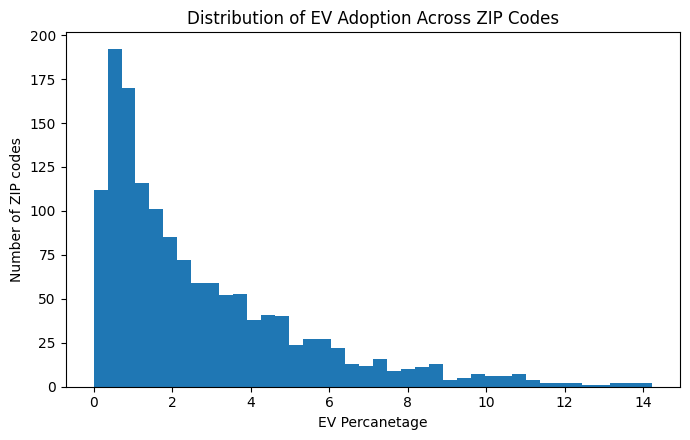

In [ ]:
# 4.1 Histogram: EV_perc distribution
plt.figure(figsize=(7,4.5))
plt.hist(df_clean["EV_perc"].dropna(), bins=40)
plt.title("Distribution of EV Adoption Across ZIP Codes")
plt.xlabel("EV Percanetage")
plt.ylabel("Number of ZIP codes")
plt.tight_layout()
plt.show()


/tmp/ipykernel_1857/2398278620.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_q = df_clean.groupby("IncomeQuintile")["EV_perc"].mean()


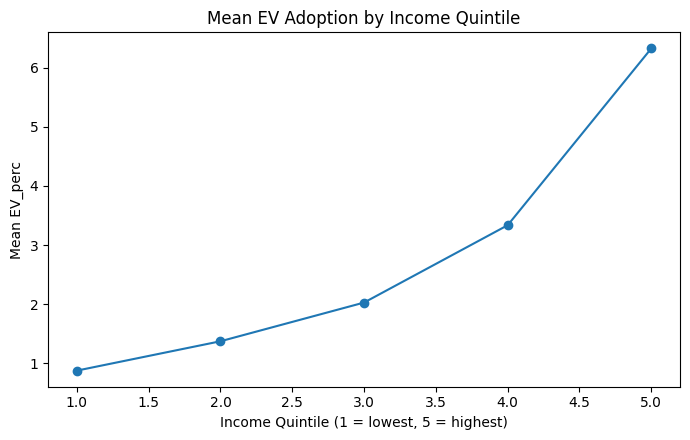

<Figure size 700x450 with 0 Axes>

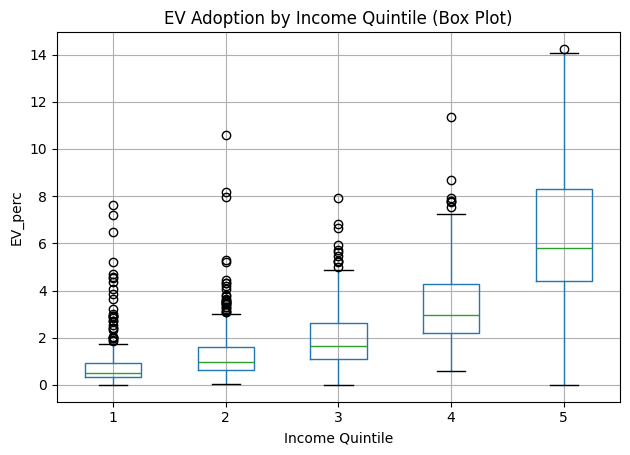

In [ ]:
# 4.2 Income quintiles


if "Median_Household_Income" in df_clean.columns:
    df_clean["IncomeQuintile"] = pd.qcut(df_clean["Median_Household_Income"], 5, labels=[1,2,3,4,5])

    mean_by_q = df_clean.groupby("IncomeQuintile")["EV_perc"].mean()

    plt.figure(figsize=(7,4.5))
    plt.plot(mean_by_q.index.astype(int), mean_by_q.values, marker="o")
    plt.title("Mean EV Adoption by Income Quintile")
    plt.xlabel("Income Quintile (1 = lowest, 5 = highest)")
    plt.ylabel("Mean EV_perc")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4.5))
    df_clean.boxplot(column="EV_perc", by="IncomeQuintile")
    plt.title("EV Adoption by Income Quintile (Box Plot)")
    plt.suptitle("")
    plt.xlabel("Income Quintile")
    plt.ylabel("EV_perc")
    plt.tight_layout()
    plt.show()

In [ ]:
#NOTE ^^

# Income quintiles split ZIP codes into five equal groups based on median income.
# Quintile 1 = lowest-income ZIP codes, Quintile 5 = highest-income ZIP codes.
# This allows us to compare EV adoption across different income levels.

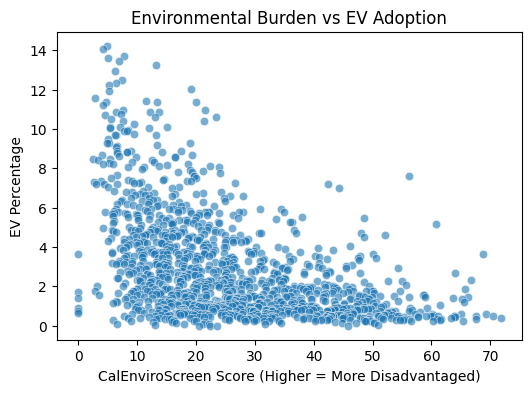

In [ ]:
import seaborn as sns
# 4.3 enviormental Budren vs EV Adoption
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df_clean,
    x="CES_Score_ZIP",
    y="EV_perc",
    alpha=0.6
)

plt.title("Environmental Burden vs EV Adoption")
plt.xlabel("CalEnviroScreen Score (Higher = More Disadvantaged)")
plt.ylabel("EV Percentage")
plt.show()

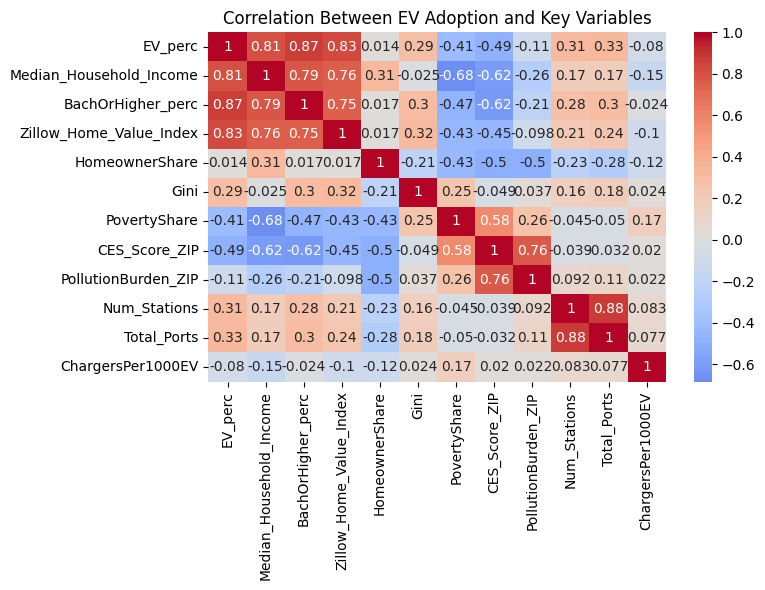

,EV_perc
BachOrHigher_perc,0.872877
Zillow_Home_Value_Index,0.832696
Median_Household_Income,0.808230
CES_Score_ZIP,-0.487001
PovertyShare,-0.414733
Total_Ports,0.331587
Num_Stations,0.314525
Gini,0.292510
PollutionBurden_ZIP,-0.108457
ChargersPer1000EV,-0.079889


In [ ]:
# 4.4 Correlation heatmap — Hypothesis variables

hyp_vars = [
    "EV_perc",
    "Median_Household_Income",
    "BachOrHigher_perc",
    "Zillow_Home_Value_Index",
    "HomeownerShare",
    "Gini",
    "PovertyShare",
    "CES_Score_ZIP",
    "PollutionBurden_ZIP",
    "Num_Stations",
    "Total_Ports",
    "ChargersPer1000EV"
]

hyp_vars = [c for c in hyp_vars if c in df_clean.columns]

corr = df_clean[hyp_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between EV Adoption and Key Variables")
plt.tight_layout()
plt.show()

# show variables most correlated with EV adoption
ev_corr = corr["EV_perc"].drop("EV_perc").sort_values(key=lambda s: s.abs(), ascending=False)
display(ev_corr)

In [ ]:
"""

Correlation analysis shows that EV adoption is strongly associated with socioeconomic factors.
The strongest correlations were observed with educational attainment (0.87), housing value (0.83), and median income (0.81).
Environmental burden indicators such as CES score (-0.49) and poverty share (-0.41) showed negative correlations with EV adoption, suggesting that disadvantaged communities tend to have lower EV adoption rates.
 Charging infrastructure variables were positively but more weakly correlated with EV adoption.

"""

<Figure size 700x450 with 0 Axes>

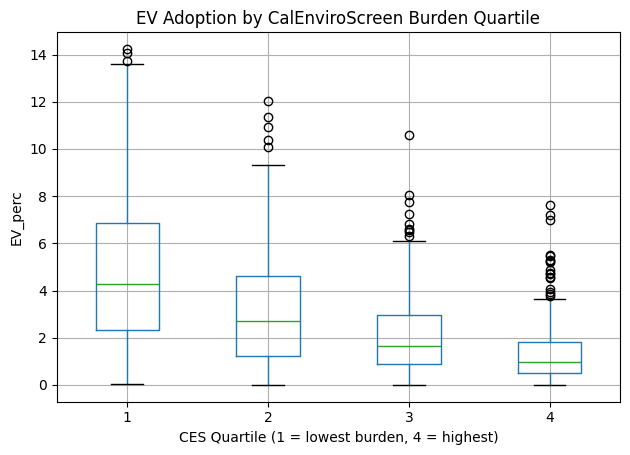

In [ ]:
# 4.5 Box plot: EV_perc by CES quartile (H1 environmental burden)
if "CES_Score_ZIP" in df_clean.columns:
    df_clean["CES_Quartile"] = pd.qcut(df_clean["CES_Score_ZIP"], 4, labels=[1,2,3,4])

    plt.figure(figsize=(7,4.5))
    df_clean.boxplot(column="EV_perc", by="CES_Quartile")
    plt.title("EV Adoption by CalEnviroScreen Burden Quartile")
    plt.suptitle("")
    plt.xlabel("CES Quartile (1 = lowest burden, 4 = highest)")
    plt.ylabel("EV_perc")
    plt.tight_layout()
    plt.show()

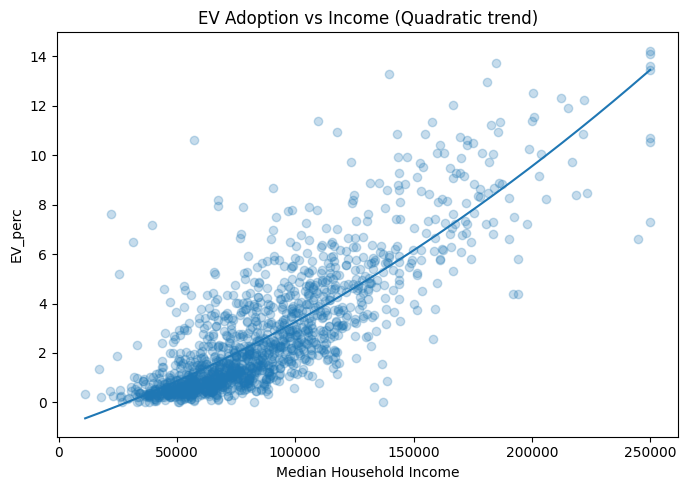

In [ ]:
# 4.6 Scatter + quadratic fit: income nonlinearity (H3)
if "Median_Household_Income" in df_clean.columns:
    d = df_clean[["Median_Household_Income","EV_perc"]].dropna()

    plt.figure(figsize=(7,5))
    plt.scatter(d["Median_Household_Income"], d["EV_perc"], alpha=0.25)
    plt.title("EV Adoption vs Income (Quadratic trend)")
    plt.xlabel("Median Household Income")
    plt.ylabel("EV_perc")

    if len(d) > 10:
        z = np.polyfit(d["Median_Household_Income"], d["EV_perc"], 2)
        p = np.poly1d(z)
        xs = np.linspace(d["Median_Household_Income"].min(), d["Median_Household_Income"].max(), 200)
        plt.plot(xs, p(xs))
    plt.tight_layout()
    plt.show()


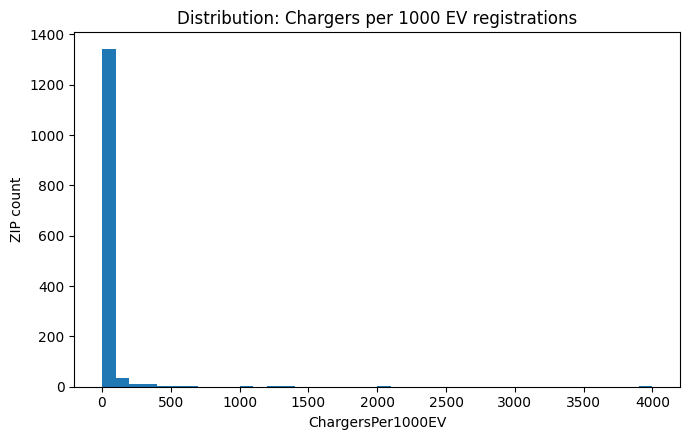

<Figure size 700x450 with 0 Axes>

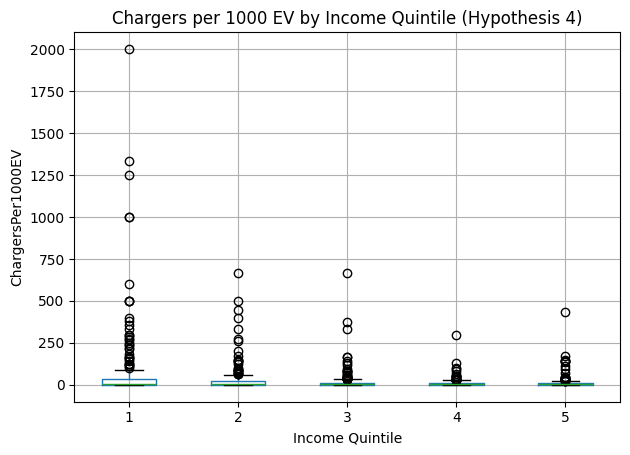

In [ ]:
# 4.7 Chargers: distribution + box by income quintile (H4)

if "ChargersPer1000EV" in df_clean.columns:
    plt.figure(figsize=(7,4.5))
    plt.hist(df_clean["ChargersPer1000EV"].dropna(), bins=40)
    plt.title("Distribution: Chargers per 1000 EV registrations")
    plt.xlabel("ChargersPer1000EV")
    plt.ylabel("ZIP count")
    plt.tight_layout()
    plt.show()

    if "IncomeQuintile" in df_clean.columns:
        plt.figure(figsize=(7,4.5))
        df_clean.boxplot(column="ChargersPer1000EV", by="IncomeQuintile")
        plt.title("Chargers per 1000 EV by Income Quintile (Hypothesis 4)")
        plt.suptitle("")
        plt.xlabel("Income Quintile")
        plt.ylabel("ChargersPer1000EV")
        plt.tight_layout()
        plt.show()

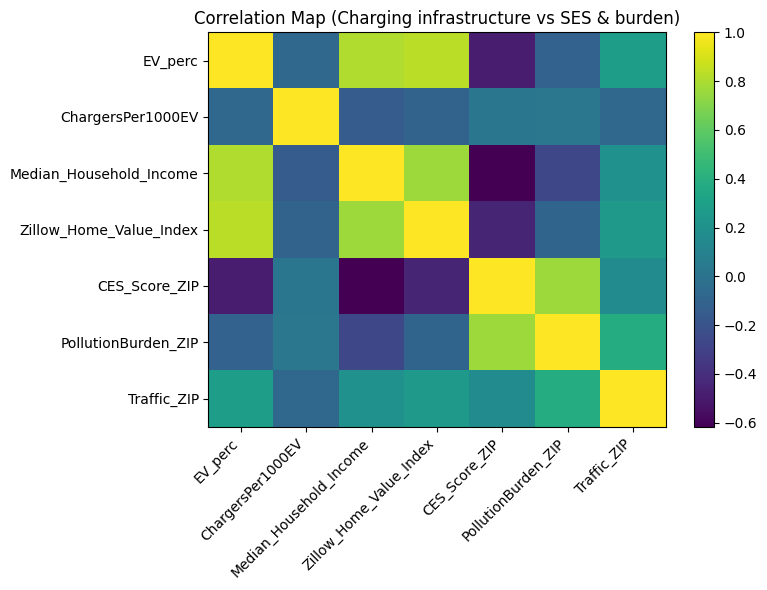

,ChargersPer1000EV
ChargersPer1000EV,1.000000
Median_Household_Income,-0.146044
Zillow_Home_Value_Index,-0.102555
EV_perc,-0.079889
Traffic_ZIP,-0.073651
PollutionBurden_ZIP,0.022296
CES_Score_ZIP,0.020499


In [ ]:
# 4.8 Correlation color map — Hypothesis 4 variables (chargers + SES + burden)
hyp4_vars = [
    "EV_perc",
    "ChargersPer1000EV",
    "Median_Household_Income",
    "Zillow_Home_Value_Index",
    "CES_Score_ZIP",
    "PollutionBurden_ZIP",
    "Traffic_ZIP"
]
hyp4_vars = [c for c in hyp4_vars if c in df_clean.columns]
if len(hyp4_vars) >= 3:
    corr4 = df_clean[hyp4_vars].corr(numeric_only=True)

    plt.figure(figsize=(8,6))
    plt.imshow(corr4, aspect="auto")
    plt.xticks(range(len(corr4.columns)), corr4.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr4.index)), corr4.index)
    plt.colorbar()
    plt.title("Correlation Map (Charging infrastructure vs SES & burden)")
    plt.tight_layout()
    plt.show()

    if "ChargersPer1000EV" in corr4.columns:
        display(corr4["ChargersPer1000EV"].sort_values(key=lambda s: s.abs(), ascending=False))


,Race-only coef,Race+SES coef
Latino_perc,-0.043569,0.005230
Asian_perc,0.073202,0.018265
Black_perc,-0.021724,0.009931


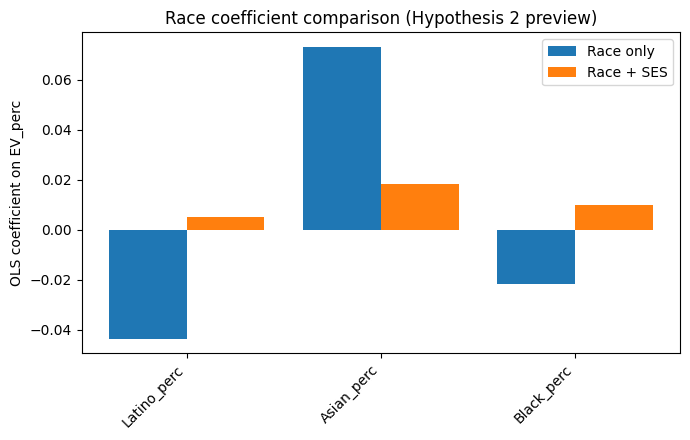

In [ ]:
# 4.9 Hypothesis 2 preview: race-only vs race+SES coefficient shrinkage
import statsmodels.api as sm

race_cols = [c for c in ["Latino_perc","White_perc","Asian_perc","Black_perc"] if c in df_clean.columns]
controls = [c for c in ["Median_Household_Income","BachOrHigher_perc","Zillow_Home_Value_Index","HomeownerShare"] if c in df_clean.columns]
race_used = [c for c in race_cols if c != "White_perc"] if "White_perc" in race_cols else race_cols

if len(race_used) >= 1:
    dA = df_clean[["EV_perc"] + race_used].dropna()
    XA = sm.add_constant(dA[race_used])
    mA = sm.OLS(dA["EV_perc"], XA).fit()

    modelB_vars = race_used + controls
    dB = df_clean[["EV_perc"] + modelB_vars].dropna()
    XB = sm.add_constant(dB[modelB_vars])
    mB = sm.OLS(dB["EV_perc"], XB).fit()

    coef_compare = pd.DataFrame({
        "Race-only coef": mA.params.reindex(race_used),
        "Race+SES coef":  mB.params.reindex(race_used)
    })
    display(coef_compare)

    plt.figure(figsize=(7,4.5))
    xpos = np.arange(len(race_used))
    plt.bar(xpos - 0.2, coef_compare["Race-only coef"], width=0.4, label="Race only")
    plt.bar(xpos + 0.2, coef_compare["Race+SES coef"],  width=0.4, label="Race + SES")
    plt.xticks(xpos, race_used, rotation=45, ha="right")
    plt.title("Race coefficient comparison (Hypothesis 2 preview)")
    plt.ylabel("OLS coefficient on EV_perc")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Race columns not found; Hypothesis 2 preview skipped.")

In [ ]:
# 5) PRELIMINARY INSIGHTS / HYPOTHESIS FORMATION

print("\n==============================")
print("5) PRELIMINARY INSIGHTS / QUESTIONS")
print("==============================")

def safe_corr(a, b):
    if a not in df_clean.columns or b not in df_clean.columns:
        return np.nan
    d = df_clean[[a,b]].dropna()
    if len(d) < 10:
        return np.nan
    return d.corr().iloc[0,1]

signals = {
    "corr(EV_perc, Income)": safe_corr("EV_perc", "Median_Household_Income"),
    "corr(EV_perc, Education)": safe_corr("EV_perc", "BachOrHigher_perc"),
    "corr(EV_perc, Home Value)": safe_corr("EV_perc", "Zillow_Home_Value_Index"),
    "corr(EV_perc, HomeownerShare)": safe_corr("EV_perc", "HomeownerShare"),
    "corr(EV_perc, Gini)": safe_corr("EV_perc", "Gini"),
    "corr(EV_perc, CES_Score_ZIP)": safe_corr("EV_perc", "CES_Score_ZIP"),
    "corr(ChargersPer1000EV, Income)": safe_corr("ChargersPer1000EV", "Median_Household_Income"),
    "corr(ChargersPer1000EV, EV_perc)": safe_corr("ChargersPer1000EV", "EV_perc"),
}
display(pd.Series(signals).dropna().sort_values(key=lambda s: s.abs(), ascending=False))



5) PRELIMINARY INSIGHTS / QUESTIONS


,0
"corr(EV_perc, Education)",0.872877
"corr(EV_perc, Home Value)",0.832696
"corr(EV_perc, Income)",0.808230
"corr(EV_perc, CES_Score_ZIP)",-0.487001
"corr(EV_perc, Gini)",0.292510
"corr(ChargersPer1000EV, Income)",-0.146044
"corr(ChargersPer1000EV, EV_perc)",-0.079889
"corr(EV_perc, HomeownerShare)",0.014079


## Further Analysis & Visualization

Text(0.5, 1.0, 'EV Adoption vs Chargers per 1000 EV')

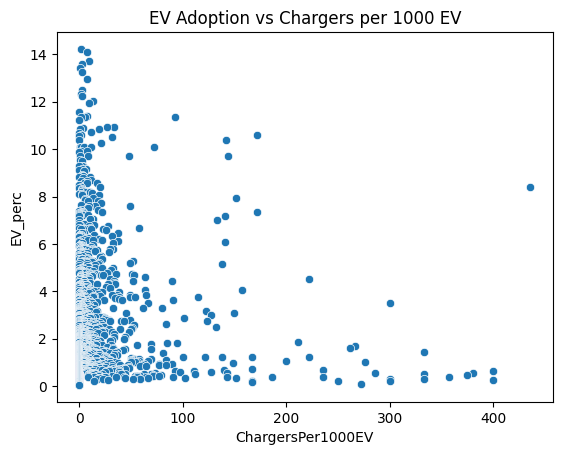

In [ ]:
# ev adoption vs chargers per 1000 ev
plot_df = df_clean[["ChargersPer1000EV", "EV_perc"]].dropna()

upper = plot_df["ChargersPer1000EV"].quantile(0.99)
plot_df = plot_df[plot_df["ChargersPer1000EV"] <= upper]

sns.scatterplot(x="ChargersPer1000EV", y="EV_perc", data=plot_df)

plt.title("EV Adoption vs Chargers per 1000 EV")

Text(0.5, 1.0, 'EV Adoption vs Charging Ports per 10,000 People')

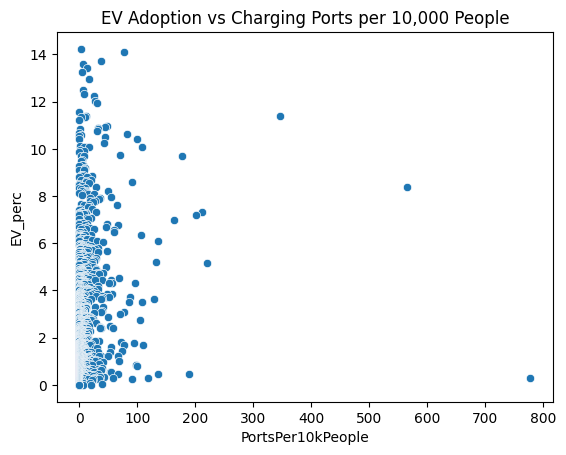

In [ ]:
# ev adoption vs charging ports per 10k people
df_clean["PortsPer10kPeople"] = (
    df_clean["Total_Ports"] / df_clean["Total_Population"]
) * 10000


sns.scatterplot(
    x="PortsPer10kPeople",
    y="EV_perc",
    data=df_clean
)
plt.title("EV Adoption vs Charging Ports per 10,000 People")

This plot examines EV adoption in relation to charging infrastructure normalized by population. Compared to the chargers-per-EV metric, this measure produces a more stable and interpretable distribution. While most ZIP codes still cluster at low levels of both infrastructure and adoption, a slight positive relationship emerges, where higher charging access per population is associated with higher EV adoption. This suggests that infrastructure availability may play a role in supporting EV adoption, although the relationship is not strongly linear and likely interacts with other socioeconomic factors.

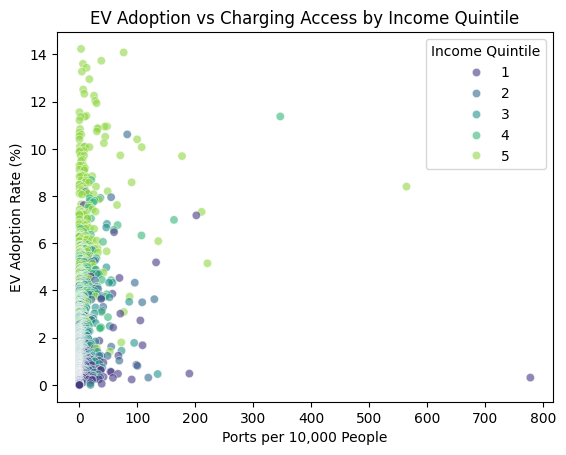

In [ ]:
# Income x Infratsructure
sns.scatterplot(
    x="PortsPer10kPeople",
    y="EV_perc",
    hue="IncomeQuintile",
    data=df_clean,
    alpha=0.6,
    palette="viridis"
)

plt.title("EV Adoption vs Charging Access by Income Quintile")
plt.xlabel("Ports per 10,000 People")
plt.ylabel("EV Adoption Rate (%)")
plt.legend(title="Income Quintile")
plt.show()

This plot examines the relationship between charging infrastructure availability and EV adoption across income quintiles. A clear separation emerges, where higher-income ZIP codes consistently exhibit higher EV adoption rates compared to lower-income ZIP codes, even at similar levels of infrastructure. This suggests that while charging access may support EV adoption, socioeconomic factors such as income play a critical role in determining the extent to which communities can benefit from available infrastructure. Overall, the results indicate that infrastructure alone is not sufficient to drive equitable EV adoption.

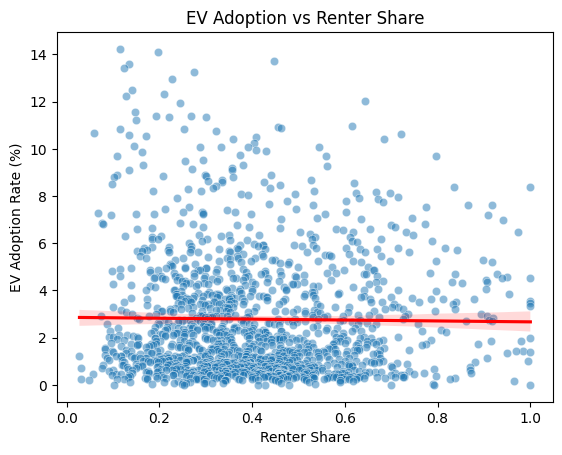

In [ ]:
# Housing Constraint (RenterShare vs EV)

sns.scatterplot(
    x="RenterShare",
    y="EV_perc",
    data=df_clean,
    alpha=0.5
)

sns.regplot(
    x="RenterShare",
    y="EV_perc",
    data=df_clean,
    scatter=False,
    color="red"
)

plt.title("EV Adoption vs Renter Share")
plt.xlabel("Renter Share")
plt.ylabel("EV Adoption Rate (%)")
plt.show()

This plot examines the relationship between housing structure and EV adoption. A slight negative trend is observed, where higher renter share is associated with lower EV adoption rates. ZIP codes with lower renter share (i.e., higher homeownership) tend to exhibit higher levels of EV adoption. This suggests that housing structure may act as a constraint, as renters are less likely to have access to private charging infrastructure. **However, the relationship is relatively weak**, indicating that while housing plays a role, other factors such as income and infrastructure availability are also important drivers of EV adoption.

/tmp/ipykernel_1857/2385303853.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_clean.groupby("IncomeQuintile")["PortsPer10kPeople"].median()


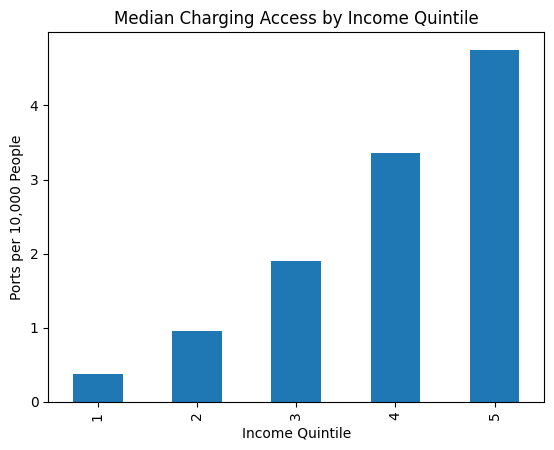

IncomeQuintile
1    0.375851
2    0.958495
3    1.904218
4    3.361922
5    4.751020
Name: PortsPer10kPeople, dtype: float64


In [ ]:
# Infrastructure Equity

summary = df_clean.groupby("IncomeQuintile")["PortsPer10kPeople"].median()

summary.plot(kind="bar")

plt.title("Median Charging Access by Income Quintile")
plt.xlabel("Income Quintile")
plt.ylabel("Ports per 10,000 People")
plt.show()

print(summary)

This plot shows a clear positive relationship between income level and charging infrastructure availability. Median charging access increases steadily across income quintiles, with the highest-income ZIP codes having more than ten times the infrastructure per population compared to the lowest-income ZIP codes. This indicates that charging infrastructure is not equitably distributed, and that higher-income communities have significantly greater access to EV charging resources. Such disparities in infrastructure availability may contribute to unequal EV adoption across communities.

In [ ]:
# Outlier/ extreme Case Analysis

top = df_clean.sort_values("EV_perc", ascending=False).head(10)

top[[
    "ZIP",
    "EV_perc",
    "Median_Household_Income",
    "BachOrHigher_perc",
    "RenterShare",
    "PortsPer10kPeople",
    "CES_Score_ZIP"
]]

,ZIP,EV_perc,Median_Household_Income,BachOrHigher_perc,RenterShare,PortsPer10kPeople,CES_Score_ZIP
0,94027,14.23,250001.0,84.7,0.115487,2.772771,4.965985
1,94022,14.08,250001.0,87.6,0.197026,76.236982,4.278299
2,94301,13.73,184932.0,82.0,0.446466,37.696457,7.792235
3,94028,13.60,250001.0,85.2,0.133763,6.077180,5.139967
4,94024,13.43,250001.0,85.1,0.123569,12.395158,6.942833
5,90402,13.27,139667.0,78.6,0.275377,4.150755,13.274099
6,92657,12.95,181176.0,78.3,0.227796,17.126954,6.298807
7,90077,12.51,200625.0,77.8,0.140738,6.469142,7.405740
8,90272,12.33,212115.0,78.9,0.209933,8.457852,6.526432
9,95070,12.25,222235.0,80.1,0.128604,25.163876,5.232542


The top EV-adopting ZIP codes exhibit consistent structural advantages across multiple dimensions. These areas have extremely high median household incomes, high levels of educational attainment, and relatively low renter shares, indicating a predominance of homeownership. They also tend to have moderate to high levels of charging infrastructure and low environmental burden scores. This suggests that EV adoption is concentrated in affluent and well-resourced communities, where both the financial capacity and physical feasibility of adopting EVs are more accessible. These findings reinforce earlier results that EV adoption disparities are driven by a combination of socioeconomic advantages and infrastructure access.

Performing Regression Analysis


In [ ]:
import statsmodels.api as sm

features = [
    "Median_Household_Income",
    "BachOrHigher_perc",
    "Zillow_Home_Value_Index",
    "PovertyShare",
    "RenterShare",
    "PortsPer10kPeople",
    "CES_Score_ZIP"
]

reg_df = df_clean[features + ["EV_perc"]].dropna()

X = reg_df[features]
y = reg_df["EV_perc"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                EV_perc   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     1375.
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:39:58   Log-Likelihood:                -1621.8
No. Observations:                1244   AIC:                             3260.
Df Residuals:                    1236   BIC:                             3301.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

- The number 1 driver : A 1% increase in college-educated population → ~0.076 increase in EV %
- followed by income and home value


A multivariate regression analysis was conducted to identify the primary drivers of EV adoption while controlling for multiple factors simultaneously. The model explains approximately 88.6% of the variation in EV adoption, indicating strong explanatory power. The results show that socioeconomic variables are the most significant predictors, with educational attainment emerging as the strongest driver, followed by income and home values. Charging infrastructure availability is also positively associated with EV adoption, although its effect is smaller relative to socioeconomic factors. Housing structure, measured through renter share, shows a negative relationship with EV adoption, suggesting potential constraints related to access to private charging. Overall, the findings indicate that EV adoption is primarily driven by socioeconomic advantage, with infrastructure and housing acting as supporting factors.

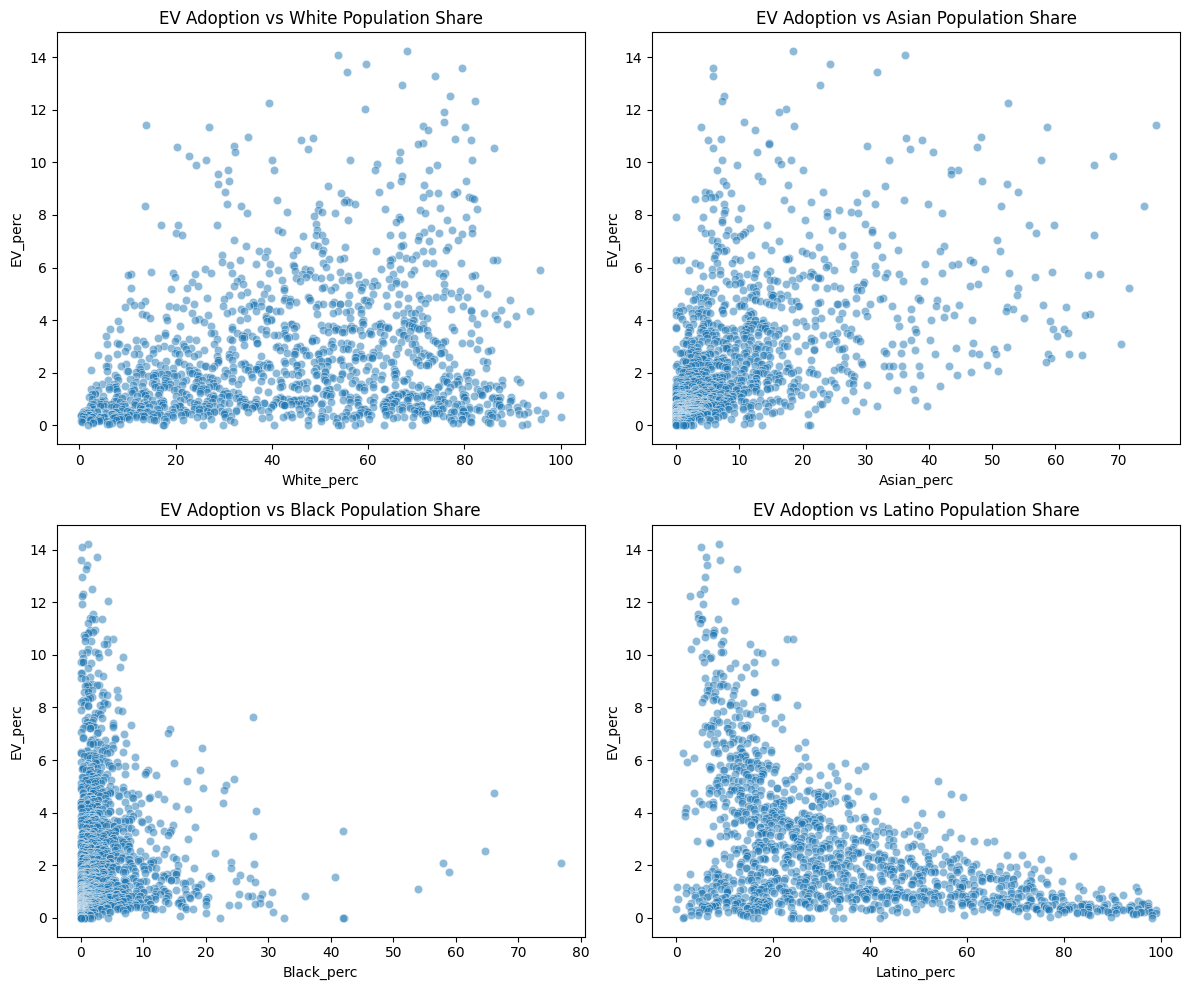

In [ ]:
# Race vs EV Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(x="White_perc", y="EV_perc", data=df_clean, ax=axes[0,0], alpha=0.5)
axes[0,0].set_title("EV Adoption vs White Population Share")

sns.scatterplot(x="Asian_perc", y="EV_perc", data=df_clean, ax=axes[0,1], alpha=0.5)
axes[0,1].set_title("EV Adoption vs Asian Population Share")

sns.scatterplot(x="Black_perc", y="EV_perc", data=df_clean, ax=axes[1,0], alpha=0.5)
axes[1,0].set_title("EV Adoption vs Black Population Share")

sns.scatterplot(x="Latino_perc", y="EV_perc", data=df_clean, ax=axes[1,1], alpha=0.5)
axes[1,1].set_title("EV Adoption vs Latino Population Share")

plt.tight_layout()
plt.show()

<Axes: xlabel='Asian_perc', ylabel='EV_perc'>

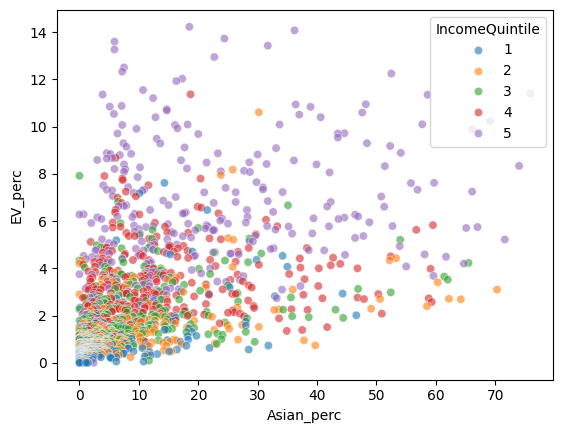

In [ ]:
# race by income - asian

sns.scatterplot(
    x="Asian_perc",
    y="EV_perc",
    hue="IncomeQuintile",
    data=df_clean,
    alpha=0.6
)

<Axes: xlabel='White_perc', ylabel='EV_perc'>

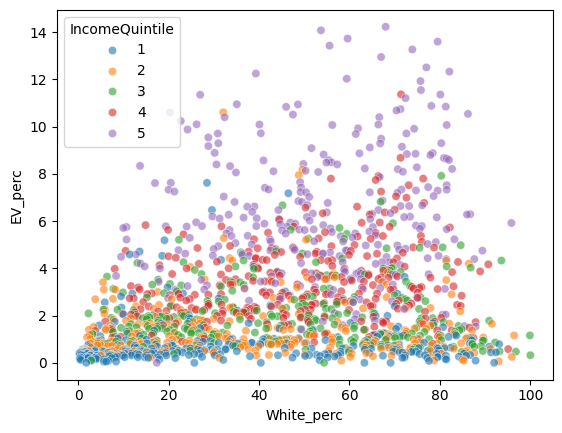

In [ ]:
# race by income - white

sns.scatterplot(
    x="White_perc",
    y="EV_perc",
    hue="IncomeQuintile",
    data=df_clean,
    alpha=0.6
)

<Axes: xlabel='Black_perc', ylabel='EV_perc'>

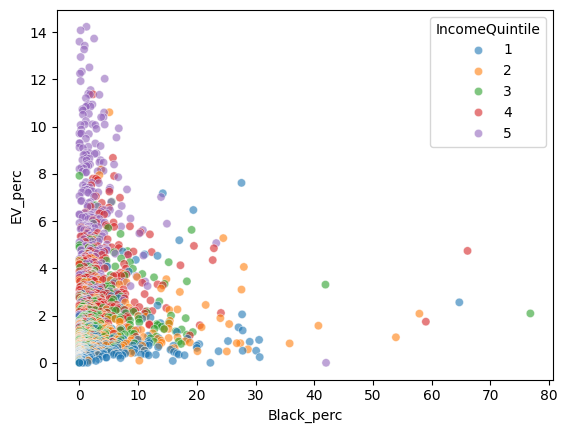

In [ ]:
# race by income - black

sns.scatterplot(
    x="Black_perc",
    y="EV_perc",
    hue="IncomeQuintile",
    data=df_clean,
    alpha=0.6
)

<Axes: xlabel='Latino_perc', ylabel='EV_perc'>

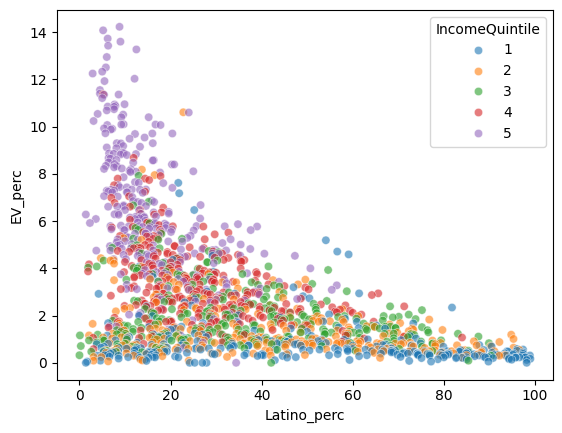

In [ ]:
# race by income - latino

sns.scatterplot(
    x="Latino_perc",
    y="EV_perc",
    hue="IncomeQuintile",
    data=df_clean,
    alpha=0.6
)

When visualizing EV adoption against racial composition while controlling for income, it becomes evident that income plays a dominant role in explaining the observed patterns. While initial plots suggested that EV adoption varies across racial groups, the color-coded income quintiles reveal that higher EV adoption is consistently concentrated in higher-income areas, regardless of racial composition

## Vehicle Composition Analysis

In [ ]:
# do areas with certain types of cars transition more easily to EVs ?

<Axes: xlabel='HybridShare', ylabel='EV_perc'>

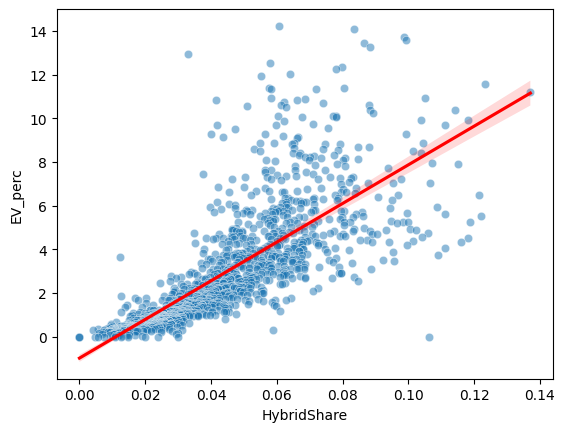

In [ ]:
df_clean["HybridShare"] = df_clean["Gasoline_Hybrid"] / df_clean["Total_Cars"]

sns.scatterplot(
    x="HybridShare",
    y="EV_perc",
    data=df_clean,
    alpha=0.5
)

sns.regplot(
    x="HybridShare",
    y="EV_perc",
    data=df_clean,
    scatter=False,
    color="red"
)

This plot shows a strong positive relationship between hybrid vehicle share and EV adoption. Areas with higher proportions of hybrid vehicles tend to exhibit significantly higher EV adoption rates. This suggests that hybrid adoption may act as a transition pathway toward full electrification, where communities already familiar with hybrid technology are more likely to adopt EVs.

<Axes: xlabel='FastShare', ylabel='EV_perc'>

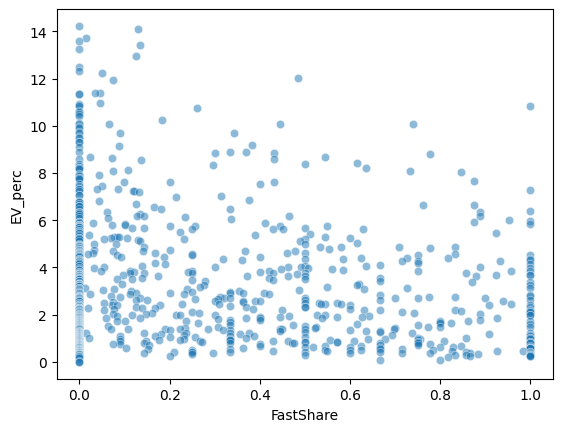

In [ ]:
df_clean["FastShare"] = df_clean["DC_Fast_Ports"] / df_clean["Total_Ports"]

sns.scatterplot(
    x="FastShare",
    y="EV_perc",
    data=df_clean,
    alpha=0.5
)

No clear relationship is observed between the share of fast chargers and EV adoption. This suggests that the presence of fast charging infrastructure alone does not strongly influence adoption rates, and that broader access to charging may be more important than charger type.

In addition to socioeconomic and infrastructure factors, vehicle composition also plays an important role in EV adoption. A strong positive relationship is observed between hybrid vehicle share and EV adoption, suggesting that hybrid adoption may act as a transition pathway toward full electrification. This indicates that communities already familiar with alternative fuel technologies are more likely to adopt EVs, highlighting the importance of behavioral and technological readiness in the transition to electric mobility.

<Axes: xlabel='ZeroVehicleShare', ylabel='EV_perc'>

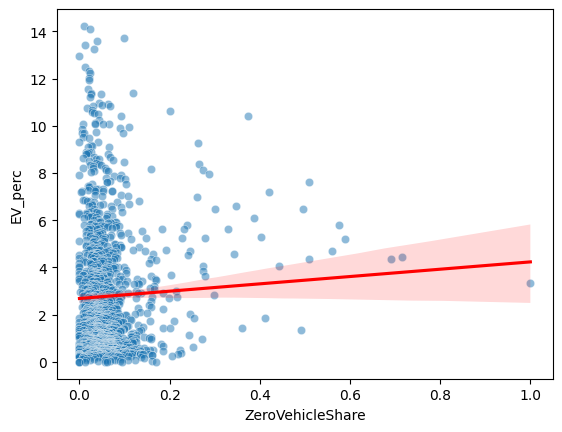

In [ ]:
# ZeroVehicleShare

sns.scatterplot(
    x="ZeroVehicleShare",
    y="EV_perc",
    data=df_clean,
    alpha=0.5
)

sns.regplot(
    x="ZeroVehicleShare",
    y="EV_perc",
    data=df_clean,
    scatter=False,
    color="red"
)

The relationship between ZeroVehicleShare and EV adoption is weak and slightly positive. This likely reflects underlying urban and socioeconomic factors, where areas with higher shares of households without vehicles may also be more urban and environmentally conscious, leading to higher EV adoption. However, the wide dispersion of points suggests that ZeroVehicleShare is not a strong independent driver of EV adoption.

<Axes: xlabel='SingleFamilyShare', ylabel='EV_perc'>

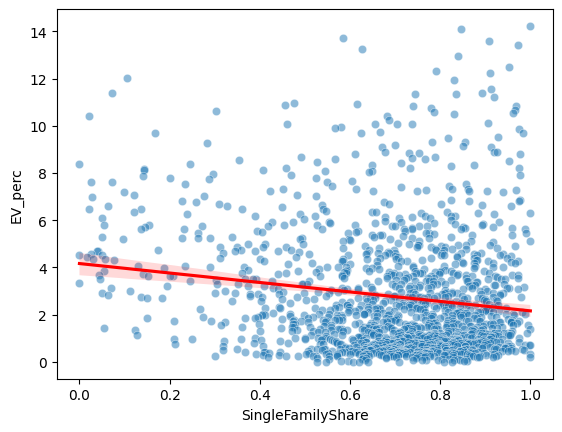

In [ ]:
# SingleFamilyShare

sns.scatterplot(
    x="SingleFamilyShare",
    y="EV_perc",
    data=df_clean,
    alpha=0.5
)

sns.regplot(
    x="SingleFamilyShare",
    y="EV_perc",
    data=df_clean,
    scatter=False,
    color="red"
)

A slight negative relationship is observed between single-family housing share and EV adoption. While single-family homes may provide better access to private charging, areas with high single-family share are often less urban and may have lower infrastructure density and different socioeconomic characteristics. This suggests that housing type alone does not determine EV adoption, and its effects are intertwined with broader geographic and socioeconomic factors.

## Interactive ZIP Map

In [ ]:
pip install plotly

In [ ]:
import json
import os

geo_path = os.path.join(DATA_DIR, "ca_california_zip_codes_geo.min.json")

with open(geo_path) as f:
    geojson = json.load(f)

In [ ]:
import plotly.express as px
import json
import os

# load geojson
geo_path = os.path.join(DATA_DIR, "ca_california_zip_codes_geo.min.json")
with open(geo_path) as f:
    geojson = json.load(f)

# make sure ZIP is formatted correctly
df_clean["ZIP"] = df_clean["ZIP"].astype(str).str.zfill(5)

# map
fig = px.choropleth(
    df_clean,
    geojson=geojson,
    locations="ZIP",
    featureidkey="properties.ZCTA5CE10",
    color="EV_perc",
    hover_data={
        "County": True,
        "Median_Household_Income": True,
        "BachOrHigher_perc": True,
        "PortsPer10kPeople": True,
        "ZIP": False  # ZIP already used for the shape, so hiding duplicate in popup
    },
    color_continuous_scale="Viridis",
    title="EV Adoption Across California ZIP Codes"
)

fig.update_geos(fitbounds="locations", visible=False)

fig.update_layout(
    margin={"r":0, "t":40, "l":0, "b":0},
    coloraxis_colorbar=dict(title="EV %")
)

fig.show()